In [1]:
import pandas as pd, numpy as np, os, json, joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/processed/features_dataset.csv")
y_log = np.log1p(df["estimated_annual_salary_lpa"])

other = ["certifications_count", "profile_completeness_pct", "log_endorsements",
         "skill_count", "education_ord", "update_ord", "connections_ord",
         "in_demand_skill_flag_bin", "open_to_work_bin", "uses_generative_ai_tools_bin"]
feature_sets = {
    "A: experience only":        (["years_experience"], []),
    "B: + seniority":            (["years_experience", "seniority_ord"], []),
    "C: full model":             (["years_experience", "seniority_ord"] + other, ["work_mode"]),
}

idx_train, idx_test = train_test_split(df.index, test_size=0.2, random_state=42)

In [2]:
def build(num, cat):
    steps = [("num", StandardScaler(), num)]
    if cat: steps.append(("cat", OneHotEncoder(drop="first"), cat))
    return Pipeline([("pre", ColumnTransformer(steps)), ("reg", LinearRegression())])

rows, models = [], {}
for name, (num, cat) in feature_sets.items():
    m = build(num, cat)
    m.fit(df.loc[idx_train, num + cat], y_log[idx_train])
    p_log = m.predict(df.loc[idx_test, num + cat])
    p_lpa = np.expm1(p_log)
    actual = df.loc[idx_test, "estimated_annual_salary_lpa"]
    rows.append({
        "model": name,
        "R2_log": r2_score(y_log[idx_test], p_log),
        "R2_LPA": r2_score(actual, p_lpa),
        "MAE_LPA": mean_absolute_error(actual, p_lpa),
        "MSE_LPA": mean_squared_error(actual, p_lpa),
        "RMSE_LPA": np.sqrt(mean_squared_error(actual, p_lpa)),
        "CV_R2_log": cross_val_score(m, df[num + cat], y_log, cv=5, scoring="r2").mean()})
    models[name] = m
results = pd.DataFrame(rows).set_index("model").round(3)
print(results)

                    R2_log  R2_LPA  MAE_LPA  MSE_LPA  RMSE_LPA  CV_R2_log
model                                                                    
A: experience only   0.819   0.065    7.435  389.664    19.740      0.817
B: + seniority       0.924   0.881    3.883   49.594     7.042      0.926
C: full model        0.939   0.905    3.511   39.449     6.281      0.940


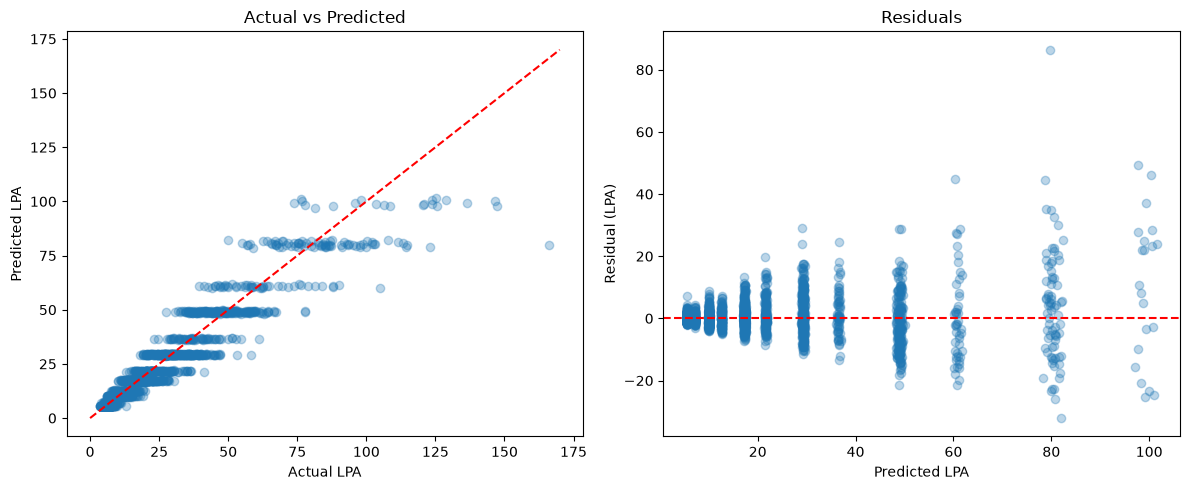

years_experience               -0.019
education_ord                  -0.002
certifications_count           -0.001
connections_ord                -0.000
work_mode_Remote                0.000
profile_completeness_pct        0.001
uses_generative_ai_tools_bin    0.001
log_endorsements                0.001
update_ord                      0.001
open_to_work_bin                0.001
skill_count                     0.002
work_mode_On-site               0.002
in_demand_skill_flag_bin        0.086
seniority_ord                   0.732
dtype: float64


In [3]:
num, cat = feature_sets["C: full model"]
m = models["C: full model"]
p = np.expm1(m.predict(df.loc[idx_test, num + cat]))
actual = df.loc[idx_test, "estimated_annual_salary_lpa"]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(actual, p, alpha=0.3); ax[0].plot([0, 170], [0, 170], "r--")
ax[0].set(xlabel="Actual LPA", ylabel="Predicted LPA", title="Actual vs Predicted")
ax[1].scatter(p, actual - p, alpha=0.3); ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="Predicted LPA", ylabel="Residual (LPA)", title="Residuals")
plt.tight_layout(); plt.savefig("../outputs/figures/10_linear_actual_vs_pred.png", dpi=150); plt.show()

# Coefficients: effect on log-salary per 1 SD of each feature
names = num + list(m.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(cat))
print(pd.Series(m.named_steps["reg"].coef_, index=names).sort_values().round(3))

In [4]:
os.makedirs("../models", exist_ok=True); os.makedirs("../outputs/metrics", exist_ok=True)
joblib.dump(models["C: full model"], "../models/linear_model.pkl")
results.to_json("../outputs/metrics/linear_metrics.json", indent=2)

In [5]:
actual = df.loc[idx_test, "estimated_annual_salary_lpa"]

# Fair raw-scale baseline for model A
raw = Pipeline([("pre", ColumnTransformer([("num", StandardScaler(), ["years_experience"])])),
                ("reg", LinearRegression())])
raw.fit(df.loc[idx_train, ["years_experience"]], actual.reindex(idx_train).fillna(df.loc[idx_train, "estimated_annual_salary_lpa"]))
print("A raw-scale R2_LPA:", round(r2_score(actual, raw.predict(df.loc[idx_test, ["years_experience"]])), 3))

# Does the in-demand flag explain the B -> C gain?
num_c, cat_c = feature_sets["C: full model"]
num_nf = [c for c in num_c if c != "in_demand_skill_flag_bin"]
m_nf = build(num_nf, cat_c)
m_nf.fit(df.loc[idx_train, num_nf + cat_c], y_log[idx_train])
print("C without flag, R2_log:", round(r2_score(y_log[idx_test], m_nf.predict(df.loc[idx_test, num_nf + cat_c])), 3))

A raw-scale R2_LPA: 0.843
C without flag, R2_log: 0.924
